# Wolf Sheep Predation

In the Mesa Wolf–Sheep agent-based model, wolves and sheep interact within a spatial environment. Sheep move across the landscape and consume grass for energy, while wolves move in search of sheep and gain energy through successful predation. Wolves and sheep lose energy as they move and may reproduce when they have sufficient resources, while individuals die when their energy is depleted. These individual-level behaviours and predator–prey interactions collectively generate population-level dynamics over time.

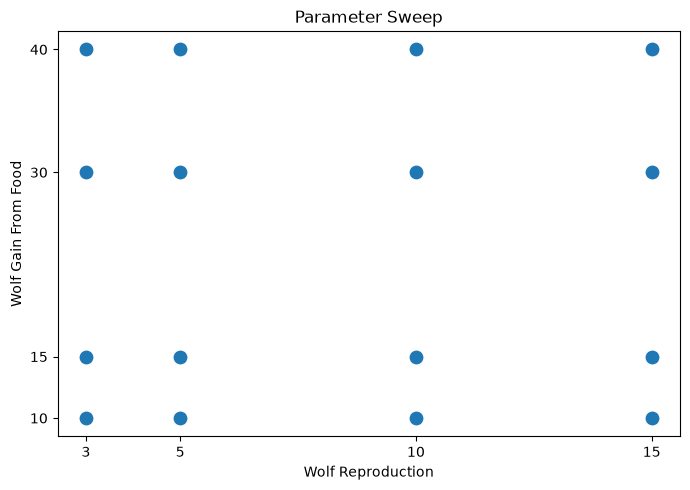

In [1]:
import itertools
import matplotlib.pyplot as plt

wolf_reproduce = [3, 5, 10, 15]
wolf_gain_from_food = [10, 15, 30, 40]

grid = list(
    itertools.product(
        wolf_reproduce,
        wolf_gain_from_food,
    )
)

x, y = zip(*grid)

plt.figure(figsize=(7, 5))

plt.scatter(x, y, s=80)

plt.xlabel("Wolf Reproduction")
plt.ylabel("Wolf Gain From Food")
plt.title("Parameter Sweep")

plt.xticks(wolf_reproduce)
plt.yticks(wolf_gain_from_food)

plt.tight_layout()
plt.show()

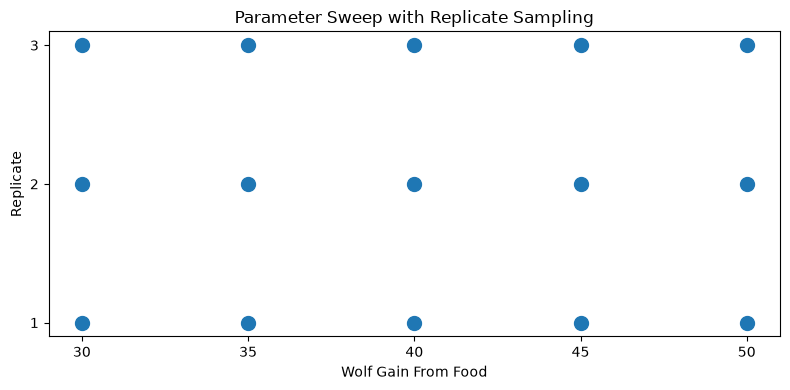

In [2]:
import numpy as np
import matplotlib.pyplot as plt

wolf_gain = np.arange(30, 51, 5)
replicates = [1, 2, 3]

x = np.repeat(wolf_gain, len(replicates))
y = np.tile(replicates, len(wolf_gain))

plt.figure(figsize=(8, 4))

plt.scatter(x, y, s=100)

plt.xlabel("Wolf Gain From Food")
plt.ylabel("Replicate")

plt.xticks(wolf_gain)
plt.yticks(replicates)

plt.title("Parameter Sweep with Replicate Sampling")

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from SALib import ProblemSpec
from caliagent.models import WolfSheep


N_STEPS = 100
N_REPLICATES = 50


def evaluate(params):
    """Mean final sheep population across replicate simulations."""

    (
        sheep_reproduce,
        wolf_reproduce,
        wolf_gain_from_food,
        grass_regrowth_time,
        sheep_gain_from_food,
    ) = params

    final_sheep = np.empty(N_REPLICATES)

    for replicate in range(N_REPLICATES):
        model = WolfSheep(
            grass=True,
            sheep_reproduce=sheep_reproduce,
            wolf_reproduce=wolf_reproduce,
            wolf_gain_from_food=wolf_gain_from_food,
            grass_regrowth_time=int(round(grass_regrowth_time)),
            sheep_gain_from_food=sheep_gain_from_food,
            seed=replicate,
        )

        for _ in range(N_STEPS):
            model.step()

        # Sheep population at the end of this simulation
        final_sheep[replicate] = model.sheep_count

    # Average final population across the 50 replicates
    return final_sheep.mean()


problem = {
    "names": [
        "sheep_reproduce",
        "wolf_reproduce",
        "wolf_gain_from_food",
        "grass_regrowth_time",
        "sheep_gain_from_food",
    ],
    "bounds": [
        [0.01, 0.10],
        [0.01, 0.10],
        [5, 40],
        [10, 50],
        [1, 10],
    ],
}


sp = ProblemSpec(problem)

sp.sample_sobol(
    128,
    calc_second_order=False,
)

Y = np.array([
    evaluate(params)
    for params in sp.samples
])

sp.set_results(Y)

sp.analyze_sobol(
    calc_second_order=False,
    print_to_console=True,
)

sensitivity = (
    pd.DataFrame({
        "Parameter": problem["names"],
        "S1": sp.analysis["S1"],
        "ST": sp.analysis["ST"],
    })
    .sort_values("ST", ascending=False)
)

print(sensitivity)

plt.figure(figsize=(8, 5))

plt.barh(
    sensitivity["Parameter"],
    sensitivity["ST"],
)

plt.xlabel("Sensitivity index")
plt.ylabel("Parameter")
plt.title(
    "Sensitivity of Final Sheep Population at 100 timesteps\n"
    "Average across 50 Replicates"
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


KeyboardInterrupt


KeyboardInterrupt



[I 2026-08-31 01:06:27,549] A new study created in memory with name: no-name-be8f225f-48cd-45a1-86f9-579eb81b4f71
[I 2026-08-31 01:06:28,278] Trial 0 finished with value: 14400.0 and parameters: {'sheep_reproduce': 0.053330573304447466, 'wolf_reproduce': 0.04307327488887063, 'wolf_gain_from_food': 33.784671794385915, 'grass_regrowth_time': 31, 'sheep_gain_from_food': 1.441791537929878}. Best is trial 0 with value: 14400.0.
[I 2026-08-31 01:06:28,300] Trial 6 finished with value: 14390.4016 and parameters: {'sheep_reproduce': 0.07330847856185045, 'wolf_reproduce': 0.018504952791525003, 'wolf_gain_from_food': 28.194828500017767, 'grass_regrowth_time': 34, 'sheep_gain_from_food': 4.262710270123458}. Best is trial 6 with value: 14390.4016.
[I 2026-08-31 01:06:28,310] Trial 1 finished with value: 14400.0 and parameters: {'sheep_reproduce': 0.0778390019899684, 'wolf_reproduce': 0.021783695260751086, 'wolf_gain_from_food': 36.3842340246704, 'grass_regrowth_time': 32, 'sheep_gain_from_food': 1

Target sheep: 120
Best error: 0.032400000000002455

Best parameters:
  sheep_reproduce: 0.09612765970416161
  wolf_reproduce: 0.09689486630315441
  wolf_gain_from_food: 6.4963243523348115
  grass_regrowth_time: 22
  sheep_gain_from_food: 7.093291458759439

Mean final sheep: 110.22
Standard deviation: 59.99042923667074


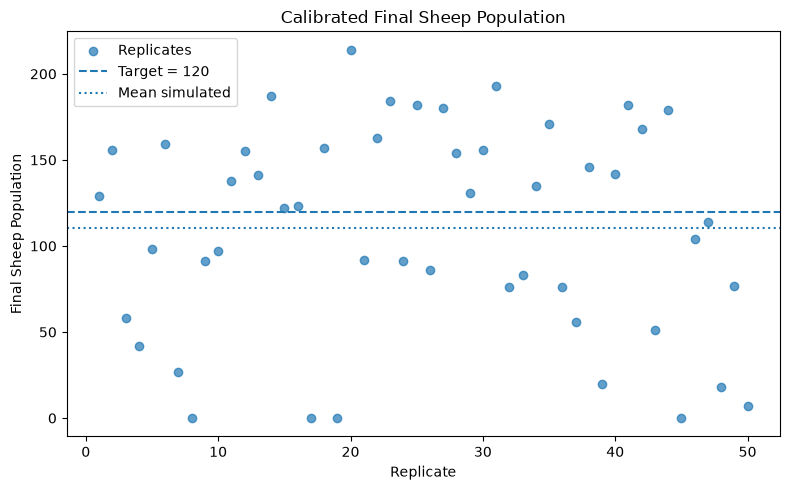

,number,value,datetime_start,datetime_complete,duration,params_grass_regrowth_time,params_sheep_gain_from_food,params_sheep_reproduce,params_wolf_gain_from_food,params_wolf_reproduce,state
0,0,14400.0000,2026-08-31 01:06:27.553341,2026-08-31 01:06:28.278873,0 days 00:00:00.725532,31,1.441792,0.053331,33.784672,0.043073,COMPLETE
1,1,14400.0000,2026-08-31 01:06:27.555714,2026-08-31 01:06:28.310599,0 days 00:00:00.754885,32,1.767567,0.077839,36.384234,0.021784,COMPLETE
2,2,14156.2404,2026-08-31 01:06:27.557459,2026-08-31 01:06:28.432379,0 days 00:00:00.874920,30,4.798142,0.025044,14.485560,0.066214,COMPLETE
3,3,14400.0000,2026-08-31 01:06:27.558902,2026-08-31 01:06:28.356560,0 days 00:00:00.797658,11,8.463820,0.025629,27.929248,0.067462,COMPLETE
4,4,14400.0000,2026-08-31 01:06:27.559844,2026-08-31 01:06:28.340577,0 days 00:00:00.780733,42,1.293938,0.073685,10.119757,0.066335,COMPLETE


In [59]:
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt

from caliagent.models import WolfSheep


# ------------------------------------------------------------
# Calibration settings
# ------------------------------------------------------------

N_STEPS = 100
N_REPLICATES = 50

TARGET_SHEEP = 120

INITIAL_SHEEP = 100
INITIAL_WOLVES = 50


# ------------------------------------------------------------
# Run replicate simulations
# ------------------------------------------------------------

def simulate_replicates(
    sheep_reproduce,
    wolf_reproduce,
    wolf_gain_from_food,
    grass_regrowth_time,
    sheep_gain_from_food,
):
    """Return final sheep counts across replicate simulations."""

    final_sheep = np.empty(N_REPLICATES)

    for replicate in range(N_REPLICATES):
        model = WolfSheep(
            initial_sheep=INITIAL_SHEEP,
            initial_wolves=INITIAL_WOLVES,
            grass=True,
            sheep_reproduce=sheep_reproduce,
            wolf_reproduce=wolf_reproduce,
            wolf_gain_from_food=wolf_gain_from_food,
            grass_regrowth_time=grass_regrowth_time,
            sheep_gain_from_food=sheep_gain_from_food,
            seed=replicate,
        )

        for _ in range(N_STEPS):
            model.step()

        final_sheep[replicate] = model.sheep_count

    return final_sheep


# ------------------------------------------------------------
# Optuna objective
# ------------------------------------------------------------

def objective(trial):
    sheep_reproduce = trial.suggest_float(
        "sheep_reproduce",
        0.01,
        0.10,
    )

    wolf_reproduce = trial.suggest_float(
        "wolf_reproduce",
        0.01,
        0.10,
    )

    wolf_gain_from_food = trial.suggest_float(
        "wolf_gain_from_food",
        5.0,
        40.0,
    )

    grass_regrowth_time = trial.suggest_int(
        "grass_regrowth_time",
        10,
        50,
    )

    sheep_gain_from_food = trial.suggest_float(
        "sheep_gain_from_food",
        1.0,
        10.0,
    )

    final_sheep = simulate_replicates(
        sheep_reproduce=sheep_reproduce,
        wolf_reproduce=wolf_reproduce,
        wolf_gain_from_food=wolf_gain_from_food,
        grass_regrowth_time=grass_regrowth_time,
        sheep_gain_from_food=sheep_gain_from_food,
    )

    mean_final_sheep = final_sheep.mean()

    error = (
        mean_final_sheep - TARGET_SHEEP
    ) ** 2

    return error


# ------------------------------------------------------------
# Optimisation
# ------------------------------------------------------------

study = optuna.create_study(
    direction="minimize",
)

study.optimize(
    objective,
    n_trials=100,
    n_jobs=8,
)


# ------------------------------------------------------------
# Best result
# ------------------------------------------------------------

print("Target sheep:", TARGET_SHEEP)
print("Best error:", study.best_value)

print("\nBest parameters:")

for parameter, value in study.best_params.items():
    print(f"  {parameter}: {value}")


# ------------------------------------------------------------
# Evaluate calibrated parameters
# ------------------------------------------------------------

best_final_sheep = simulate_replicates(
    **study.best_params,
)

print(
    "\nMean final sheep:",
    best_final_sheep.mean(),
)

print(
    "Standard deviation:",
    best_final_sheep.std(),
)


# ------------------------------------------------------------
# Plot replicate outcomes
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    np.arange(1, N_REPLICATES + 1),
    best_final_sheep,
    alpha=0.7,
    label="Replicates",
)

plt.axhline(
    TARGET_SHEEP,
    linestyle="--",
    label="Target = 120",
)

plt.axhline(
    best_final_sheep.mean(),
    linestyle=":",
    label="Mean simulated",
)

plt.xlabel("Replicate")
plt.ylabel("Final Sheep Population")
plt.title("Calibrated Final Sheep Population")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Optuna trials
# ------------------------------------------------------------

trials = study.trials_dataframe()

trials.head()

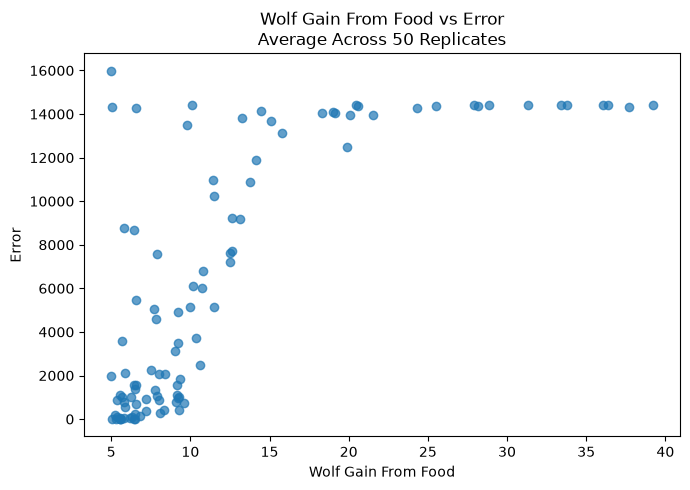

In [70]:
trials = study.trials_dataframe().sort_values("value")

import matplotlib.pyplot as plt

param_cols = [
    "params_wolf_gain_from_food",

]

for param in param_cols:
    plt.figure(figsize=(7, 5))

    plt.scatter(
        trials[param],
        trials["value"],
        alpha=0.7,
    )

    plt.xlabel(
        param.replace("params_", "").replace("_", " ").title()
    )
    plt.ylabel("Error")
    plt.title("Wolf Gain From Food vs Error\n""Average Across 50 Replicates")

    plt.tight_layout()
    plt.show()

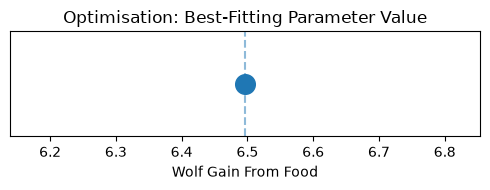

In [83]:
best_trial = trials.loc[trials["value"].idxmin()]

best_value = best_trial["params_wolf_gain_from_food"]

plt.figure(figsize=(5, 2))

plt.scatter(
    best_value,
    0,
    s=200,
)

plt.axvline(
    best_value,
    linestyle="--",
    alpha=0.5,
)

plt.xlabel("Wolf Gain From Food")
plt.yticks([])
plt.title("Optimisation: Best-Fitting Parameter Value")

plt.tight_layout()
plt.show()

ABC.Sampler INFO: Parallelize sampling on 16 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-08-31 12:31:03>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 9.85000000e+01.
ABC INFO: Accepted: 200 / 371 = 5.3908e-01, ESS: 2.0000e+02.
ABC INFO: Timing t=0 [s]: total=7.25, simulation=6.99 (96%), pipeline-setup=0.00254, prepare-next=0.116 (population-size=0.00495, distance=0.00105).
ABC INFO: t: 1, eps: 5.40000000e+01.
ABC INFO: Accepted: 200 / 522 = 3.8314e-01, ESS: 7.3682e+01.
ABC INFO: Timing t=1 [s]: total=7.74, simulation=7.5 (97%), pipeline-setup=0.00221, prepare-next=0.0108 (population-size=0.00234, distance=0.00032).
ABC INFO: t: 2, eps: 3.26635305e+01.
ABC INFO: Accepted: 200 / 636 = 3.1447e-01, ESS: 1.2726e+02.
ABC INFO: Timing t=2 [s]: total=7.41, simulation=7.27 (98%), pipeline-setup=0.00087, prepare-next=0.0116 (population-size=0.00252, distance=0.000284).
ABC INFO: t: 3, eps: 1.60000000e+01.
ABC INFO: Accepted: 200 / 773 = 2.5873e-01, ESS: 1.2040e+

name  grass_regrowth_time  sheep_gain_from_food  sheep_reproduce  \
id                                                                 
1002            40.117165              9.224082         0.076253   
1003            17.831017              4.985532         0.094113   
1004            18.678427              5.352051         0.081162   
1005            32.524644              7.296735         0.062392   
1006            24.840984              8.261579         0.050314   

name  wolf_gain_from_food  wolf_reproduce    weight  
id                                                   
1002             4.800369        0.079824  0.003117  
1003             5.577588        0.071351  0.012781  
1004             7.733725        0.016970  0.003272  
1005             6.193539        0.031028  0.004284  
1006             6.546819        0.044663  0.002316  

Posterior means:
sheep_reproduce: 0.066
wolf_reproduce: 0.053
wolf_gain_from_food: 6.249
grass_regrowth_time: 24.150
sheep_gain_from_food: 7.121

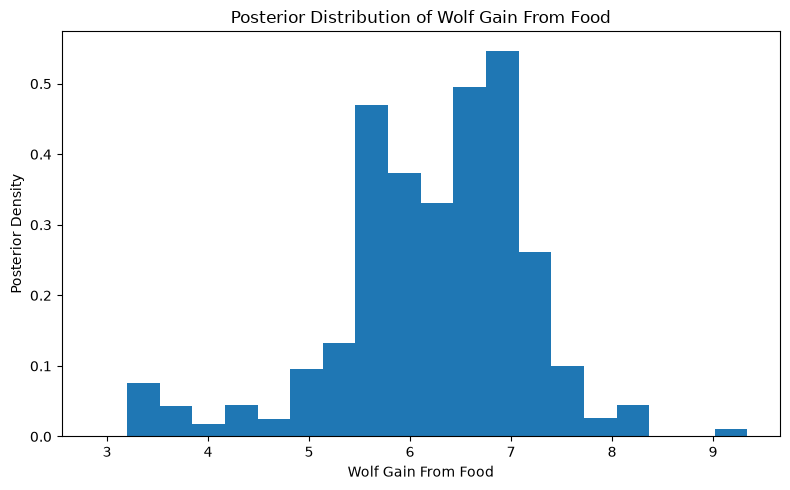

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyabc

from caliagent.models import WolfSheep


# ------------------------------------------------------------
# Calibration settings
# ------------------------------------------------------------

N_STEPS = 100

TARGET_SHEEP = 120

INITIAL_SHEEP = 100
INITIAL_WOLVES = 50


# ------------------------------------------------------------
# pyABC model
# ------------------------------------------------------------

def model(parameters):
    """Run one stochastic Wolf-Sheep simulation."""

    model = WolfSheep(
        initial_sheep=INITIAL_SHEEP,
        initial_wolves=INITIAL_WOLVES,
        grass=True,
        sheep_reproduce=parameters["sheep_reproduce"],
        wolf_reproduce=parameters["wolf_reproduce"],
        wolf_gain_from_food=parameters["wolf_gain_from_food"],
        grass_regrowth_time=int(
            round(parameters["grass_regrowth_time"])
        ),
        sheep_gain_from_food=parameters["sheep_gain_from_food"],
    )

    for _ in range(N_STEPS):
        model.step()

    return {
        "final_sheep": model.sheep_count,
    }


# ------------------------------------------------------------
# Prior distributions
# ------------------------------------------------------------

prior = pyabc.Distribution(
    sheep_reproduce=pyabc.RV(
        "uniform",
        0.01,
        0.09,
    ),
    wolf_reproduce=pyabc.RV(
        "uniform",
        0.01,
        0.09,
    ),
    wolf_gain_from_food=pyabc.RV(
        "norm",
        6.5,
        1.0,
    ),
    grass_regrowth_time=pyabc.RV(
        "uniform",
        10.0,
        40.0,
    ),
    sheep_gain_from_food=pyabc.RV(
        "uniform",
        1.0,
        9.0,
    ),
)


# ------------------------------------------------------------
# Observed data
# ------------------------------------------------------------

observed = {
    "final_sheep": TARGET_SHEEP,
}


# ------------------------------------------------------------
# Distance function
# ------------------------------------------------------------

def distance(simulated, observed):
    """Absolute difference from target sheep population."""

    return abs(
        simulated["final_sheep"]
        - observed["final_sheep"]
    )


# ------------------------------------------------------------
# ABC-SMC
# ------------------------------------------------------------

abc = pyabc.ABCSMC(
    model,
    prior,
    distance,
    population_size=200
)

abc.new(
    "sqlite://",
    observed,
)

history = abc.run(
    minimum_epsilon=5.0,
    # max_nr_populations=1000,
    # max_total_nr_simulations=1000, 
    # min_acceptance_rate=0.0
)


# ------------------------------------------------------------
# Posterior samples
# ------------------------------------------------------------

posterior, weights = history.get_distribution(
    m=0,
    t=history.max_t,
)

posterior["weight"] = weights

print(posterior.head())


# ------------------------------------------------------------
# Posterior summaries
# ------------------------------------------------------------

parameters = [
    "sheep_reproduce",
    "wolf_reproduce",
    "wolf_gain_from_food",
    "grass_regrowth_time",
    "sheep_gain_from_food",
]

print("\nPosterior means:")

for parameter in parameters:
    posterior_mean = np.average(
        posterior[parameter],
        weights=posterior["weight"],
    )

    print(
        f"{parameter}: {posterior_mean:.3f}"
    )


# ------------------------------------------------------------
# Plot posterior for wolf gain from food
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    posterior["wolf_gain_from_food"],
    weights=posterior["weight"],
    bins=20,
    density=True,
)

plt.xlabel("Wolf Gain From Food")
plt.ylabel("Posterior Density")
plt.title(
    "Posterior Distribution of Wolf Gain From Food"
)

plt.tight_layout()
plt.show()

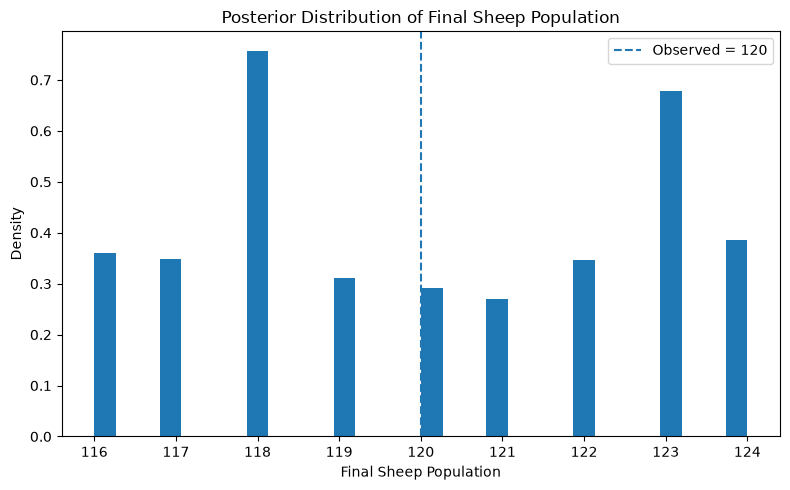

In [4]:
weights, sum_stats = history.get_weighted_sum_stats_for_model(
    m=0,
    t=history.max_t,
)

final_sheep = np.array([
    stat["final_sheep"]
    for stat in sum_stats
])

plt.figure(figsize=(8, 5))

plt.hist(
    final_sheep,
    weights=weights,
    bins=30,
    density=True,
)

plt.axvline(
    TARGET_SHEEP,
    linestyle="--",
    label="Observed = 120",
)

plt.xlabel("Final Sheep Population")
plt.ylabel("Density")
plt.title("Posterior Distribution of Final Sheep Population")
plt.legend()

plt.tight_layout()
plt.show()

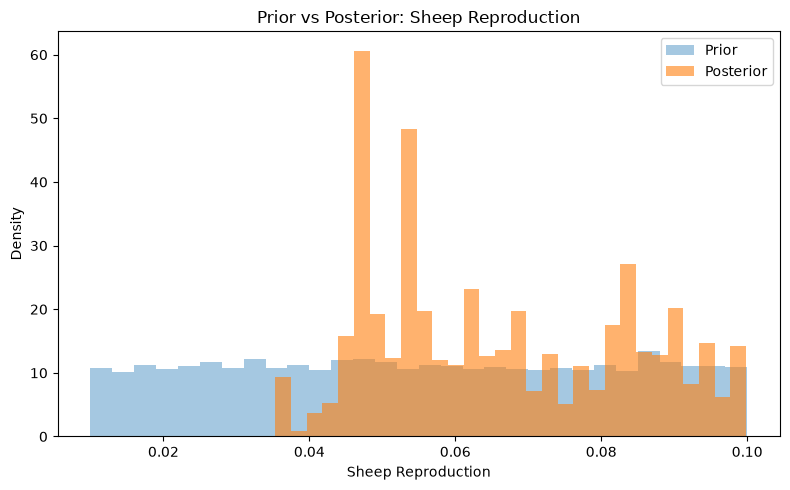

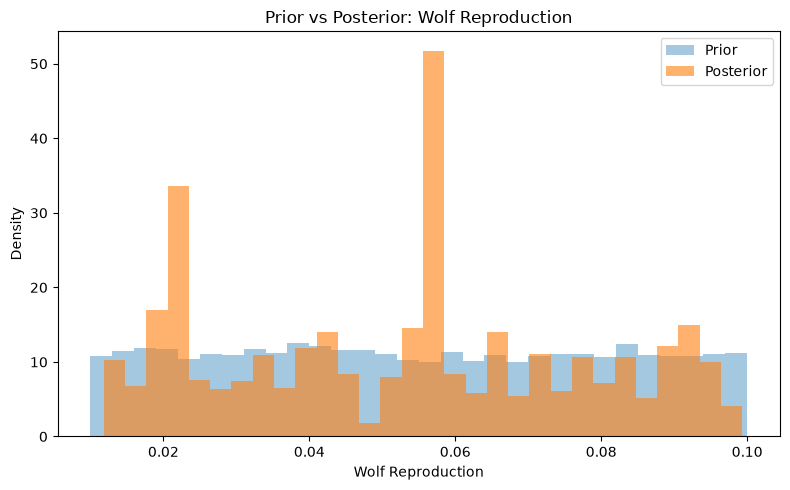

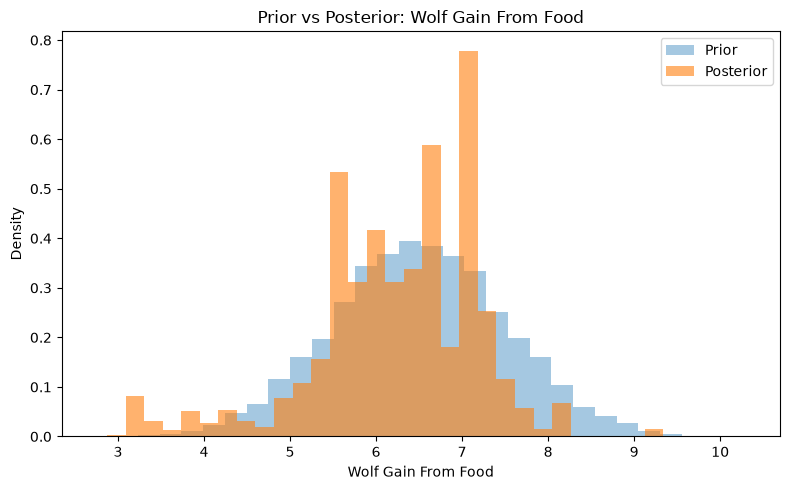

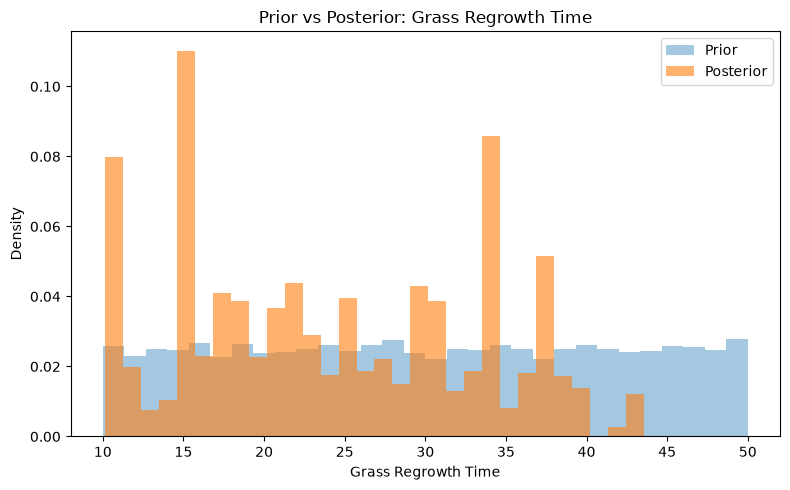

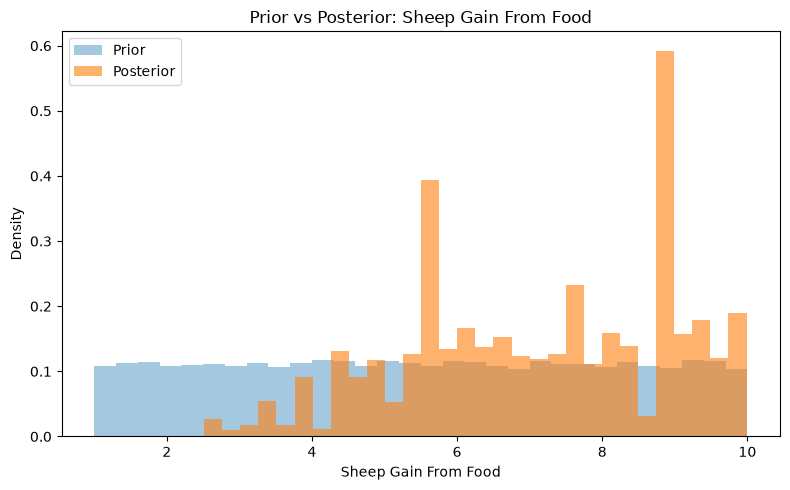

In [9]:
import numpy as np
import matplotlib.pyplot as plt


parameters = {
    "sheep_reproduce": "Sheep Reproduction",
    "wolf_reproduce": "Wolf Reproduction",
    "wolf_gain_from_food": "Wolf Gain From Food",
    "grass_regrowth_time": "Grass Regrowth Time",
    "sheep_gain_from_food": "Sheep Gain From Food",
}


# Posterior from final pyABC population
posterior, weights = history.get_distribution(
    m=0,
    t=history.max_t,
)


for parameter, label in parameters.items():

    # Draw samples from prior
    prior_samples = prior[parameter].rvs(
        size=10000
    )

    plt.figure(figsize=(8, 5))

    # Prior
    plt.hist(
        prior_samples,
        bins=30,
        density=True,
        alpha=0.4,
        label="Prior",
    )

    # Posterior
    plt.hist(
        posterior[parameter],
        weights=weights,
        bins=30,
        density=True,
        alpha=0.6,
        label="Posterior",
    )

    plt.xlabel(label)
    plt.ylabel("Density")
    plt.title(f"Prior vs Posterior: {label}")
    plt.legend()

    plt.tight_layout()
    plt.show()